In [42]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 클래스 0 데이터
X0 = np.random.normal(loc=[1.5, 1.5], scale=0.5, size=(50, 2))

# 클래스 1 데이터
X1 = np.random.normal(loc=[4.0, 3.5], scale=0.5, size=(50, 2))

# 전체 입력 데이터
X = np.vstack([X0, X1])

# 정답 라벨
t = np.array([0] * 50 + [1] * 50)

# 이미 학습된 것처럼 가정한 가중치와 편향
w = np.array([1.0, 1.0])
b = -5.0
X0

array([[1.74835708, 1.43086785],
       [1.82384427, 2.26151493],
       [1.38292331, 1.38293152],
       [2.28960641, 1.88371736],
       [1.26526281, 1.77128002],
       [1.26829115, 1.26713512],
       [1.62098114, 0.54335988],
       [0.63754108, 1.21885624],
       [0.99358444, 1.65712367],
       [1.04598796, 0.79384815],
       [2.23282438, 1.38711185],
       [1.5337641 , 0.78762591],
       [1.22780864, 1.55546129],
       [0.92450321, 1.68784901],
       [1.19968066, 1.35415313],
       [1.19914669, 2.42613909],
       [1.49325139, 0.97114454],
       [1.91127246, 0.88957818],
       [1.6044318 , 0.52016494],
       [0.83590698, 1.59843062],
       [1.86923329, 1.58568414],
       [1.44217586, 1.34944815],
       [0.760739  , 1.1400779 ],
       [1.26968061, 2.02856111],
       [1.67180914, 0.61847992],
       [1.66204198, 1.30745886],
       [1.161539  , 1.80583814],
       [2.01549976, 1.96564006],
       [1.08039124, 1.34539381],
       [1.66563172, 1.98777256],
       [1.

### 로지스틱 회귀의 선형점수 함수식
$$
\Large z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

$$
\Large z = w^Tx + b
$$


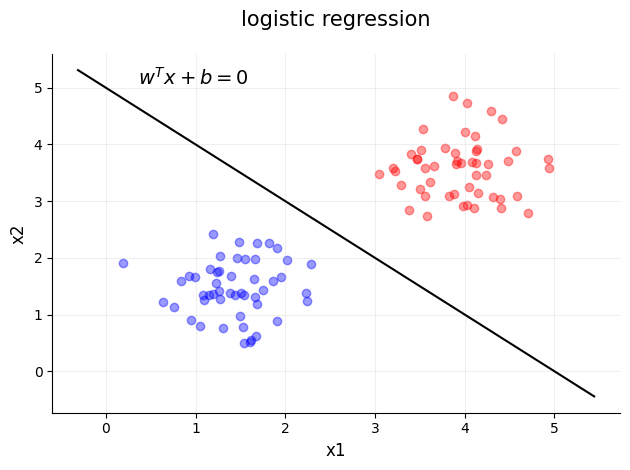

In [43]:
# 로지스틱 회귀 선형 점수 함수식
z = np.dot(X, w) + b # w: 가중치, x: 입력 벡터, b: 편향
color = 'br'

x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max()+0.5, 100)
x2 = -((w[0]*x1 + b)/w[1])

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for x, c in zip([X0, X1], color):
    plt.scatter(x[:, 0], x[:, 1], color=c, alpha=0.4)
plt.plot(x1, x2, color='black')
plt.title('logistic regression', fontsize=15, pad=20)
plt.text(x1[8]+0.2, x2[8]+0.2, '$w^T x + b = 0$', fontsize=14)
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.grid( alpha=0.2)
plt.tight_layout()
plt.show()


### 로지스틱 회귀의 활성화 함수: 시그모이드(로지스틱) 함수식

$$
\Large predicted \space p = \frac {1}{1+e^{-z}}
$$ 

$$
\Large predicted \space p = \frac {1}{1+e^{w^T x + b}}
$$

**($-\infty$ ~ $\infty$) 범위의 z 값을 (-1 ~ 1) 범위로 변환 $\Rightarrow$ 확률 표현**

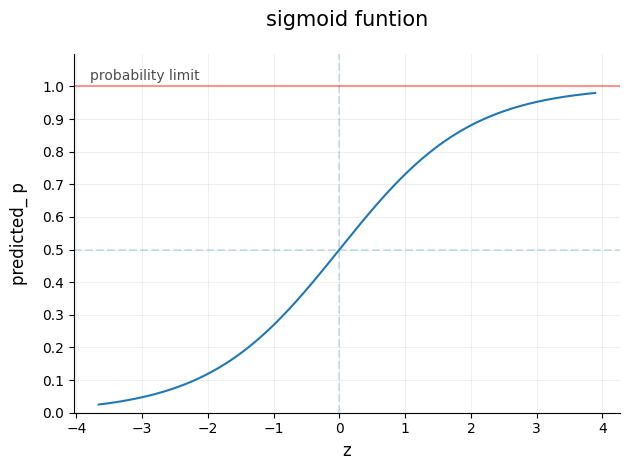

In [44]:
# 활성화 함수: 시그모이드 함수(로지스틱 함수)
z = np.dot(X, w) + b
p = 1 / (1 + np.exp(-z))

x_sig = np.linspace(z.min()-0.5, z.max(), 10000)
p_sig = 1/(1+np.exp(-x_sig))


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.plot(x_sig, p_sig)
plt.title('sigmoid funtion', fontsize=15, pad=20)
plt.xticks(np.arange(-4, 4.1, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.1)
plt.text(-3.8, 1.02, 'probability limit', fontsize=10, alpha=0.7)
plt.ylabel('predicted_ p', fontsize=12, labelpad=10)
plt.xlabel('z', fontsize=12, loc='center')
plt.axvline(0, linestyle='--', alpha=0.2)
plt.axhline(1, linestyle='-', color='red', alpha=0.4)
plt.axhline(0.5, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.grid(True, linestyle='-', alpha=0.2)
plt.show()

C:\Users\박중현\AppData\Local\Temp\ipykernel_18664\3283771541.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


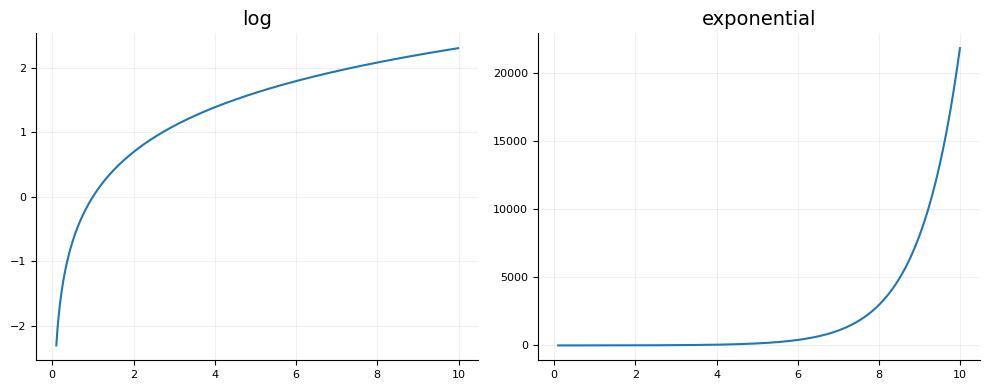

In [45]:
# 로그함수, 지수함수 비교
a = np.arange(0.1, 10, 0.01)
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(a, np.log(a))
axs[0].set_title('log', fontsize=14)
axs[0].tick_params(axis='both', labelsize=8)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].grid(linestyle='-', alpha=0.2)
axs[1].plot(a, np.exp(a))
axs[1].tick_params(axis='both', labelsize=8)
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].grid(linestyle='-', alpha=0.2)
axs[1].set_title('exponential', fontsize=14)
fig.tight_layout()
fig.show()

### 로지스틱 회귀 분석의 손실 함수: 크로스 엔트로피 손실 함수식

$$
\Large E = - [\space t \log(p) + (1-t)\log(1-p)\space]
$$

$$
\text {if } t = 1
$$
$$
E = -\log(p)
$$

$$
\text {if } t = 0
$$
$$
E = \log(1-p)
$$

C:\Users\박중현\AppData\Local\Temp\ipykernel_18664\4186139876.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


array([0.04154377, 0.05148277, 0.06152154, 0.07166211, 0.08190656,
       0.09225706, 0.1027158 , 0.11328509, 0.12396729, 0.13476482,
       0.14568022, 0.15671608, 0.16787509, 0.17916003, 0.19057377,
       0.20211929, 0.21379967, 0.2256181 , 0.23757787, 0.24968242,
       0.26193527, 0.27434013, 0.2869008 , 0.29962125, 0.3125056 ,
       0.32555813, 0.33878328, 0.35218567, 0.36577014, 0.37954169,
       0.39350555, 0.40766716, 0.4220322 , 0.43660661, 0.45139658,
       0.46640858, 0.48164938, 0.49712607, 0.51284605, 0.5288171 ,
       0.54504737, 0.56154541, 0.57832021, 0.59538121, 0.61273835,
       0.6304021 , 0.64838346, 0.66669409, 0.68534626, 0.70435295,
       0.72372791, 0.74348569, 0.76364172, 0.78421239, 0.80521512,
       0.82666844, 0.84859211, 0.87100722, 0.89393632, 0.91740352,
       0.94143469, 0.96605761, 0.99130215, 1.01720053, 1.0437875 ,
       1.07110069, 1.09918089, 1.12807243, 1.15782358, 1.18848708,
       1.22012065, 1.25278768, 1.28655799, 1.32150872, 1.35772

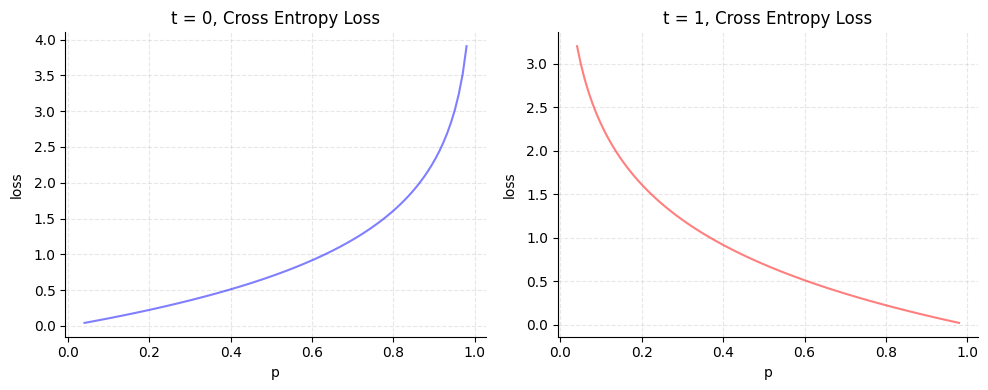

In [46]:
# 손실함수 (크로스 엔트로피 손실 함수)
E = -1 * (t * np.log(p) + (1-t) * np.log(1 - p)) # 개별 데이터 크로스 엔트로피 손실 함수
E_total = - 1 * np.sum((t * np.log(p) + (1-t) * np.log(1 - p))) # 손실함수의 총합

# 손실함수 그래프 그리기
def cross_entropy_loss(p):
    eps = 1e-15
    p_clip = np.clip(p, eps, 1 - eps)
    loss_list = {}
    p_grid = np.linspace(p_clip.min(), p_clip.max(), 100)
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    for (t, c) in zip([0, 1], 'br'):
        E = -1 * (t * np.log(p_grid) + (1-t) * np.log(1 - p_grid))
        loss_list[t] = E
        axs[t].plot(p_grid, E, color=c, alpha=0.5)
        axs[t].set_title(f't = {t}, Cross Entropy Loss')
        axs[t].set_xlabel('p')
        axs[t].set_ylabel('loss', labelpad=7)
        axs[t].spines["right"].set_visible(False)
        axs[t].spines['top'].set_visible(False)
        axs[t].grid(linestyle='--', alpha=0.3)
    fig.tight_layout()                                                                                                                                                                                                
    fig.show()
    return loss_list
result = cross_entropy_loss(p)
result[0]                                                                                                                                                                                                                                                       

### 로지스틱 회귀 모델 설계 구조

1. 입력: 특징 행렬(X), 타깃 레이블 벡터(T), 학습률(eta), 에포크(epochs)
2. 결과: w, b, 손실 트렌드, 파라미터 변화 트렌드(w, b)

3. 순서 (*배치 학습일 경우 z와 p를 2차원 벡터 전체로, 가중치 조정시 특성 별 평균 기반 기울기 정의*)
    - w, b 가정
    - 에포크 수 만큼 반복
    - z 정의 및 계산
    - p 정의 및 계산
    - loss 정의 및 계산, 리스트 포함
    - p와 T 기반 가중치 조정
    - 결과값 리턴 및 종료

epoch 0
w조정: [0.15959514 0.08500132], b조정: -0.14036003287986606
epoch 1
w조정: [0.25764715 0.12460646], b조정: -0.29560154056224297
epoch 2
w조정: [0.33022262 0.1445995 ], b조정: -0.4512562744405113
epoch 3
w조정: [0.40189898 0.16871806], b조정: -0.5991202308710564
epoch 4
w조정: [0.44174802 0.16701633], b조정: -0.7509035449526746
epoch 5
w조정: [0.44636706 0.13175547], b조정: -0.9081483945149332
epoch 6
w조정: [0.48994898 0.1373211 ], b조정: -1.0458070274756346
epoch 7
w조정: [0.4921545  0.10750311], b조정: -1.1904669404992094
epoch 8
w조정: [0.59195297 0.17024712], b조정: -1.2970237089703893
epoch 9
w조정: [0.64396891 0.19360861], b조정: -1.4145642038850659
epoch 10
w조정: [0.64228361 0.16805825], b조정: -1.5455640871998382
epoch 11
w조정: [0.66129435 0.16172403], b조정: -1.6646435358589038
epoch 12
w조정: [0.72826278 0.2009283 ], b조정: -1.76290593553238
epoch 13
w조정: [0.74350675 0.19402373], b조정: -1.8749820012558929
epoch 14
w조정: [0.76668619 0.19535872], b조정: -1.980469909435823
epoch 15
w조정: [0.7909582  0.20046192], b조정: -2.0813

C:\Users\박중현\AppData\Local\Temp\ipykernel_18664\520503506.py:136: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


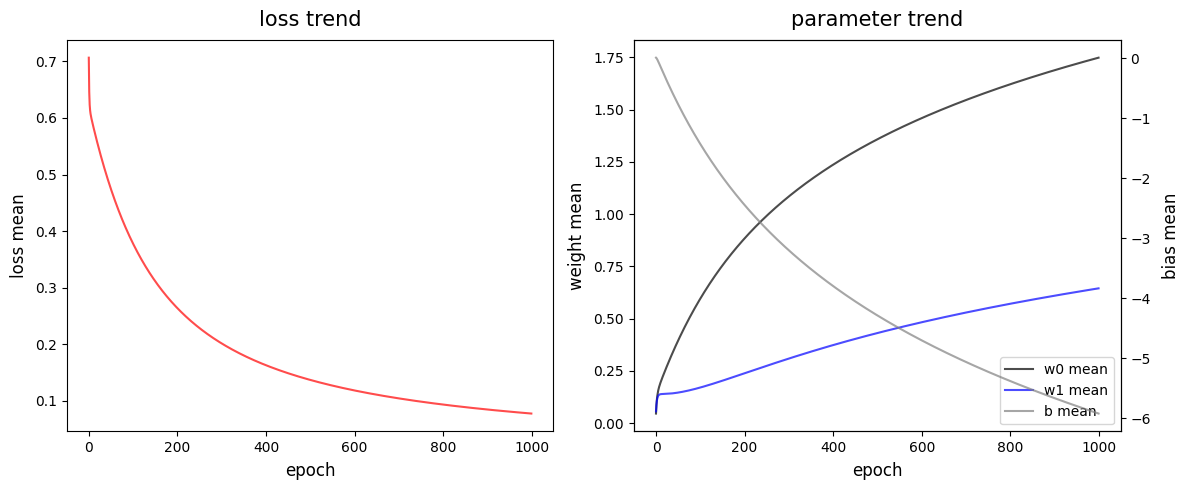

In [ ]:
# 로지스틱 모델 구현

    # 1. 확률적경사하강법
def logistic_regression_sgd(X, T, eta, epochs): # X: 입력 행렬, T: 정답 라벨 벡터, eta: 학습률
    loss_history = []
    loss_per_epoch_history = []
    # 초기 임의 가중치, 편향 설정
    w = np.random.normal(0, 0.01, X.shape[1])
    b = 0.01     
    eps = 1e-15
    for epoch in range(epochs):
        print(f"epoch {epoch}")
        loss_per_epoch = 0
        
        idx = np.random.permutation(len(X))
        for i in idx:
            x = X[i]
            t = T[i]
                   
            # 선형점수 설계
            z = np.dot(w, x) + b
                
            # 예측확률 설계
            p = 1 / (1 + np.exp(-z)) 
                
            # 엡실론 기반 오류 보정(손실함수 계산 목적)
            p_clip = np.clip(p, eps, 1-eps) 
                
            # 크로스 엔트로피 손실함수 설계
            e = -(t * np.log(p_clip) + (1-t) * np.log(1-p_clip))
                
            loss_per_epoch += e
            loss_history.append(e)
                
                
            # 파라미터 조정
            w += -(eta) * (p - t) * x
            b += -(eta) * (p - t)
            
        loss_per_epoch_history.append(loss_per_epoch/len(T))    
        
        print(f"w조정: {w}, b조정: {b}")
        
    return w, b, loss_history, loss_per_epoch_history

def logistic_regression_prob(X, T, eta, epochs):
    w, b, l, e = logistic_regression_sgd(X, T, eta, epochs)
    prob_list = []
    pred_list = []
    
    z = np.dot(X, w) + b
    
    prob = 1 / (1 + np.exp(-z))
    pred = (prob >= 0.5).astype('int')
    accuracy = np.mean(pred == T)
    
    prob_list.append(prob)
    pred_list.append(pred)
    
    predict = np.array(pred_list)
    predict_proba = np.array(prob_list)
       
    return predict, predict_proba, accuracy, l, e

pred, prob, accuracy, loss_history, loss_epoch = logistic_regression_prob(X, t, 0.01, 1000)



    # 2. 배치학습법
def logistic_regression_batch(X, T, epochs=100, eta = 0.1):
    W = np.random.normal(0, 0.01, X.shape[1])
    b = 0.01
    eps = 1e-15
    loss_history = []
    W_history = []
    b_history = []
    
    for epoch in range(epochs):
        print("-" * 30)
        print(f"epoch {epoch}")
        
        # 샘플 전체 선형점수(1차원 배열로 계산 속도 제고)
        Z = np.ravel(np.dot(X, W) + b)
        
        # 샘플 전체 예측 확률 벡터
        P = 1 / (1 + np.exp(-Z)) 
        
        # 샘플 전체 크로스엔트로피 오류 도출 후 평균
        P_range = np.clip(P, eps, 1-eps)
        
        E = -(T * np.log(P_range) + (1 - T) * np.log(1 - P_range))
        E_mean = np.mean(E) # 샘플 전체 크로스엔트로피 오류 도출 후 평균
        
        # 오차 트렌드 기록
        loss_history.append(E_mean)
        
        # 가중치 조정
        dW = np.dot(X.T, (P-T)) / len(T)
        db = np.mean(P - T)
        
        W += -(eta)*dW
        b += -(eta)*db
        print(f"w 조정:{W}, b 조정:{b}")
        
        # 가중치 조정 트렌드 기록
        W_history.append(W.copy())
        b_history.append(b)
        
    return W, b, loss_history, np.array(W_history), np.array(b_history)

w, b, loss, w_history, b_history = logistic_regression_batch(X, t, 1000)


# 결과값 트렌드 그래프 그리기
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(range(len(loss)), loss, alpha=0.7, color='r')
axs[0].set_title('loss trend', fontsize=15, pad = 10)
axs[0].set_xlabel('epoch', fontsize=12, labelpad=5)
axs[0].set_ylabel('loss mean', fontsize=12, labelpad=5)

ax1 = axs[1]
ax2 = ax1.twinx()
axs[1].plot(range(len(w_history)), w_history[:, 0], alpha=0.7, color='black', label='w0 mean')
axs[1].plot(range(len(w_history)), w_history[:, 1], alpha=0.7, color='blue', label='w1 mean')
ax2.plot(range(len(b_history)), b_history, alpha=0.7, color='grey', label = 'b mean')
axs[1].set_title('parameter trend', fontsize=15, pad = 10)
axs[1].set_xlabel('epoch', fontsize=12, labelpad=5)
axs[1].set_ylabel('weight mean', fontsize=12, labelpad=5)
ax2.set_ylabel('bias mean', fontsize=12, labelpad=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc = "lower right")

fig.tight_layout()
fig.show()        
        


epoch 0
w조정: [0.7137892  0.15239348], b조정: -1.4716352344371586
epoch 1
w조정: [1.02765989 0.25783823], b조정: -2.4711824304326093
epoch 2
w조정: [1.01609197 0.12400143], b조정: -3.3163087039403716
epoch 3
w조정: [1.17105673 0.2285344 ], b조정: -3.9285720540748423
epoch 4
w조정: [1.48339583 0.48136996], b조정: -4.361571233338242
epoch 5
w조정: [1.5132518  0.45472703], b조정: -4.8121424262371635
epoch 6
w조정: [1.63278669 0.55121068], b조정: -5.155350604747315
epoch 7
w조정: [1.69324085 0.58430236], b조정: -5.482222921041017
epoch 8
w조정: [1.73474439 0.59414471], b조정: -5.774111445627843
epoch 9
w조정: [1.77264704 0.6205685 ], b조정: -6.039384280563368
epoch 10
w조정: [1.86479003 0.69931197], b조정: -6.25868457797359
epoch 11
w조정: [1.91712638 0.73686465], b조정: -6.473917061350257
epoch 12
w조정: [1.85007673 0.64790577], b조정: -6.714695907401819
epoch 13
w조정: [2.04658132 0.81618813], b조정: -6.845062159517846
epoch 14
w조정: [2.07242068 0.82799919], b조정: -7.025042423374949
epoch 15
w조정: [2.03743366 0.787801  ], b조정: -7.21726672519162

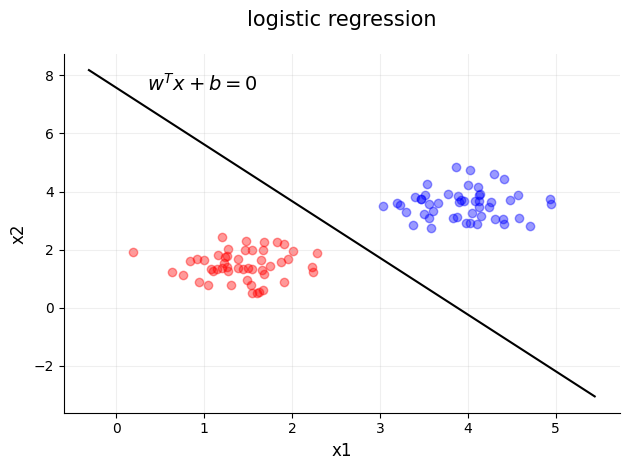

In [48]:

w, b, loss, loss_epoch = logistic_regression_sgd(X, t, 0.1, 100)

x1 = np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 100)
x2 = -((w[0]*x1 + b)/w[1])
pred = np.ravel(pred)

X0 = X[pred == 0]
X1 = X[pred == 1]

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for x, c in zip([X0, X1], 'rb'):
    plt.scatter(x[:, 0], x[:, 1], color=c, alpha=0.4)
plt.plot(x1, x2, color='black')
plt.title('logistic regression', fontsize=15, pad=20)
plt.text(x1[8]+0.2, x2[8]+0.2, '$w^T x + b = 0$', fontsize=14)
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.grid( alpha=0.2)
plt.tight_layout()
plt.show()

